# **분류 실습**

# **캐글 산탄데르 고객 만족 예측**

## 1) XGBoost 사용

In [ ]:
# 1. 산탄데르 고객 만족 데이터셋 로드
#    데이터의 전체적인 규모와 상위 샘플을 확인하는 데이터 탐색(EDA)의 첫 단계

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

# 실행 시 발생하는 불필요한 경고 메시지를 차단
warnings.filterwarnings('ignore')

# CSV 파일 로드
cust_df = pd.read_csv("./train_santander.csv", encoding='latin-1')

# 데이터의 행(건수)과 열(피처) 크기를 출력하여 데이터 규모를 확인
print('dataset shape:', cust_df.shape)

# 데이터의 상위 3개 행을 출력하여 데이터 구성을 확인
cust_df.head(3)

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [17]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [ ]:
# 2. 타겟 값 분포 확인 및 불만족 고객 비율 계산
#    TARGET 레이블의 분포를 파악하여 데이터 불균형 정도를 확인하는 과정

In [18]:
# TARGET 컬럼의 값 종류별 데이터 건수를 출력
print(cust_df['TARGET'].value_counts())

# 불만족 고객(TARGET이 1인 경우)의 총 건수 계산
unsatisfied_cnt = cust_df[cust_df['TARGET'] == 1].TARGET.count()

# 전체 데이터의 총 건수 계산
total_cnt = cust_df.TARGET.count()

# 전체 고객 중 불만족 고객이 차지하는 비율을 소수점 둘째 자리까지 출력
print('unsatisfied 비율은 {0:.2f}'.format((unsatisfied_cnt / total_cnt)))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은 0.04


In [19]:
cust_df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [ ]:
# 3. 데이터 전처리 및 피처/레이블 세트 분리
#    결측치 처리와 불필요한 컬럼 제거 후, 학습에 필요한 피처 데이터와 타겟 레이블을 분리하는 과정

In [20]:
# 'var3' 컬럼에 있는 이상치(-999999)를 가장 빈번한 값인 2로 대체
cust_df['var3'].replace(-999999, 2, inplace=True)

# 단순 식별자인 ID 컬럼은 예측에 도움이 되지 않으므로 드롭
cust_df.drop('ID', axis=1, inplace=True)

# 피처 세트와 레이블 세트 분리. 레이블 컬럼은 맨 마지막에 위치하므로 -1 인덱스로 분리
X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]

# 분리된 피처 데이터의 크기(shape) 확인
print('피처 데이터 shape:{0}'.format(X_features.shape))

피처 데이터 shape:(76020, 369)


In [ ]:
# 4. 학습 데이터와 테스트 데이터 세트 분리
#    전체 데이터를 학습용과 평가용으로 나누고, 레이블(Target)의 분포가 균형 있게 분할되었는지 확인하는 과정

In [21]:
from sklearn.model_selection import train_test_split

# 학습 데이터와 테스트 데이터를 8:2 비율로 분리 (random_state로 결과 고정)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels,
                                                    test_size=0.2, random_state=0)

# 분리된 데이터 세트의 건수 계산
train_cnt = y_train.count()
test_cnt = y_test.count()

# 학습 세트와 테스트 세트의 피처 데이터 모양(Shape) 출력
print('학습 세트 Shape:{0}, 테스트 세트 Shape:{1}'.format(X_train.shape, X_test.shape))

# 학습 세트의 레이블(Target) 값 분포 비율 확인
print(' 학습 세트 레이블 값 분포 비율')
print(y_train.value_counts()/train_cnt)

# 테스트 세트의 레이블(Target) 값 분포 비율 확인 (학습 세트와 유사한지 비교)
print('\n 테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts()/test_cnt)

학습 세트 Shape:(60816, 369), 테스트 세트 Shape:(15204, 369)
 학습 세트 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64

 테스트 세트 레이블 값 분포 비율
TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


In [22]:
# X_train, y_train을 다시 학습과 검증 데이터 세트로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=0)

In [ ]:
# 5. XGBoost 모델 학습 및 성능 평가
#    XGBClassifier를 이용해 모델을 학습시키고, 조기 중단 기능을 적용하여 최적의 ROC AUC 점수를 도출하는 과정

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# 수정: early_stopping_rounds와 eval_metric을 객체 생성 시점에 포함
xgb_clf = XGBClassifier(n_estimators=500,
                        learning_rate=0.05,
                        random_state=156,
                        early_stopping_rounds=100, # 객체 생성 시 설정
                        eval_metric="auc")         # 객체 생성 시 설정

# fit() 단계에서는 검증 데이터 세트(eval_set)만 지정하여 학습을 수행
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])

# 테스트 데이터 세트의 예측 확률값을 기반으로 ROC AUC 성능 평가
xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1])
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.84104	validation_1-auc:0.81454
[1]	validation_0-auc:0.84488	validation_1-auc:0.81613
[2]	validation_0-auc:0.84812	validation_1-auc:0.81844
[3]	validation_0-auc:0.85180	validation_1-auc:0.81988
[4]	validation_0-auc:0.85424	validation_1-auc:0.82153
[5]	validation_0-auc:0.85771	validation_1-auc:0.82355
[6]	validation_0-auc:0.85919	validation_1-auc:0.82479
[7]	validation_0-auc:0.86097	validation_1-auc:0.82580
[8]	validation_0-auc:0.86158	validation_1-auc:0.82608
[9]	validation_0-auc:0.86252	validation_1-auc:0.82734
[10]	validation_0-auc:0.86337	validation_1-auc:0.82816
[11]	validation_0-auc:0.86438	validation_1-auc:0.82862
[12]	validation_0-auc:0.86544	validation_1-auc:0.82971
[13]	validation_0-auc:0.86660	validation_1-auc:0.83028
[14]	validation_0-auc:0.86727	validation_1-auc:0.83086
[15]	validation_0-auc:0.86787	validation_1-auc:0.83148
[16]	validation_0-auc:0.86869	validation_1-auc:0.83203
[17]	validation_0-auc:0.86900	validation_1-auc:0.83223
[18]	validation_0-au

In [ ]:
# 6. Hyperopt를 이용한 XGBoost 하이퍼 파라미터 검색 공간 설정
#    베이지안 최적화를 위해 각 하이퍼 파라미터의 범위와 분포를 정의하는 과정

In [24]:
from hyperopt import hp

# XGBoost의 하이퍼 파라미터 검색 공간 정의
xgb_search_space = {
    # 5에서 15까지 1 간격으로 정수형 값을 검색
    'max_depth': hp.quniform('max_depth', 5, 15, 1),

    # 자식 노드에 필요한 최소 가중치 합을 1에서 6까지 1 간격으로 검색
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),

    # 각 트리 학습 시 샘플링할 컬럼 비율을 0.5에서 0.95 사이 균등 분포로 검색
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.95),

    # 학습률을 0.01에서 0.2 사이 균등 분포된 값으로 검색
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
}

In [ ]:
# 7. Hyperopt 목적 함수(Objective Function) 설정
#    교차 검증(K-Fold)을 통해 하이퍼 파라미터의 성능을 평가하고 최적화 목표값을 반환하는 함수 정의

In [25]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

# fmin()에서 호출 시 search_space 값으로 XGBClassifier 교차 검증 학습 후 -1 * roc_auc 평균 값을 반환
def objective_func(search_space):
    # 수정: early_stopping_rounds와 eval_metric을 객체 생성 시점에 포함
    xgb_clf = XGBClassifier(n_estimators=100,
                            max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            colsample_bytree=search_space['colsample_bytree'],
                            learning_rate=search_space['learning_rate'],
                            early_stopping_rounds=30, # 객체 생성 시 설정
                            eval_metric="auc")        # 객체 생성 시 설정

    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    roc_auc_list = []
    # 3개 k-fold 방식 적용
    kf = KFold(n_splits=3)

    # X_train을 다시 학습과 검증용 데이터로 분리
    for tr_index, val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 index 값으로 데이터 세트 분리
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        # fit() 단계에서는 검증 데이터 세트(eval_set)만 지정하여 학습을 수행
        xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])

        # 검증 데이터로 예측 확률값 추출 후 roc auc 계산하여 리스트에 추가
        score = roc_auc_score(y_val, xgb_clf.predict_proba(X_val)[:, 1])
        roc_auc_list.append(score)

    # HyperOpt는 최솟값을 찾으므로, 정확도의 평균값에 -1을 곱하여 반환
    return -1 * np.mean(roc_auc_list)

In [ ]:
# 8. Hyperopt를 이용한 베이지안 최적화 수행
#    설정한 검색 공간과 목적 함수를 기반으로 최적의 하이퍼 파라미터를 찾아내는 과정

In [ ]:
from hyperopt import fmin, tpe, Trials

# 최적화 과정의 결과를 저장할 Trials 객체 생성
trials = Trials()

# fmin() 함수를 호출하여 최적의 하이퍼 파라미터 추출
# max_evals에 지정된 횟수만큼 반복하며 목적함수의 최솟값을 가지는 입력값을 검색
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest, # 최적화 알고리즘으로 TPE(Tree-structured Parzen Estimator) 사용
            max_evals=50,     # 최대 반복 횟수를 지정
            trials=trials,    # 결과 저장소 지정
            rstate=np.random.default_rng(seed=30)) # 결과 재현을 위한 난수 시드 설정

# 찾아낸 최적의 하이퍼 파라미터 조합 출력
print('best:', best)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[70]	validation_0-auc:0.85346	validation_1-auc:0.83372
[71]	validation_0-auc:0.85337	validation_1-auc:0.83363
[72]	validation_0-auc:0.85363	validation_1-auc:0.83374
[73]	validation_0-auc:0.85387	validation_1-auc:0.83394
[74]	validation_0-auc:0.85404	validation_1-auc:0.83417
[75]	validation_0-auc:0.85419	validation_1-auc:0.83423
[76]	validation_0-auc:0.85435	validation_1-auc:0.83438
[77]	validation_0-auc:0.85456	validation_1-auc:0.83445
[78]	validation_0-auc:0.85474	validation_1-auc:0.83449
[79]	validation_0-auc:0.85480	validation_1-auc:0.83443
[80]	validation_0-auc:0.85501	validation_1-auc:0.83470
[81]	validation_0-auc:0.85494	validation_1-auc:0.83459
[82]	validation_0-auc:0.85500	validation_1-auc:0.83451
[83]	validation_0-auc:0.85514	validation_1-auc:0.83453
[84]	validation_0-auc:0.85514	validation_1-auc:0.83458
[85]	validation_0-auc:0.85514	validation_1-auc:0.83452
[86]	validation_0-auc:0.85519	validation_1-auc:0.83443
[87]	validation_0-auc:0.85534

In [ ]:
# 너무 오래 걸려서 중간 개념정리

---

## **베이지안 최적화와 Hyperopt의 이해**

### 1. 베이지안 최적화 (Bayesian Optimization)
머신러닝 모델에는 사용자가 직접 설정해야 하는 하이퍼 파라미터(학습률, 트리 깊이 등)라는 수많은 **다이얼**이 존재한다. 이 다이얼들을 최적으로 조합하여 모델의 성능을 극대화하는 과정을 최적화라고 한다.

*   **기존 방식 (Grid Search)**: 모든 다이얼 조합을 하나씩 대입해보는 무차별 대입 방식이다. 경우의 수가 많아질수록 시간이 기하급수적으로 소요된다.
*   **베이지안 방식**: 이전의 실행 결과를 토대로 성능이 잘 나올 법한 위치를 영리하게 추측하며 탐색한다. "저번 결과가 좋았던 지점 근처를 더 파보자"는 식의 확률적 판단을 내린다.
*   **핵심**: 과거의 경험을 바탕으로 다음 탐색 지점을 결정하므로, 불필요한 시도를 줄이는 효율적인 탐색법이다.


### 2. Hyperopt 라이브러리의 역할
베이지안 최적화라는 수학적 이론을 파이썬에서 실제 코드로 구현할 수 있게 돕는 도구다. 주요 구성 요소는 다음과 같다.

*   **목적 함수 (Objective Function)**: 특정 파라미터 조합을 넣었을 때 모델을 학습시키고 성능 점수를 반환하는 함수다.
*   **검색 공간 (Search Space)**: 각 파라미터가 가질 수 있는 값의 범위(예: 0~100)와 분포를 설정한다.
*   **fmin() 함수**: Hyperopt의 핵심 엔진이다. 설정된 알고리즘을 통해 목적 함수의 결괏값(오차 등)을 최소화하는 최적의 파라미터 조합을 찾아낸다.



### 3. 실행 시간이 오래 걸리는 이유 (Troubleshooting)
베이지안 최적화가 영리한 탐색을 한다고 해서 개별 모델 학습의 물리적인 속도 자체가 빨라지는 것은 아니다.

1.  **반복 학습의 누적**: 파라미터를 한 번 바꿀 때마다(Iteration) 모델을 처음부터 끝까지 새로 학습시켜야 한다.
2.  **교차 검증 (K-Fold)의 영향**: 모델 하나당 데이터를 여러 번 나누어 학습(K-Fold=3일 경우 3번 학습)하므로 연산량이 배로 늘어난다.
3.  **총 연산 횟수**: 만약 `max_evals=50`, `K-Fold=3`이라면, **XGBoost라는 무거운 모델을 총 150번 생성하고 학습**하는 셈이다.

> **결론**: 현재 작업이 느린 것은 무한 루프에 빠진 것이 아니라, 대량의 모델 학습 연산을 정직하게 수행하고 있기 때문이다. 실습 시에는 데이터 샘플링이나 반복 횟수 조절을 통해 속도 타협이 필요할 수 있다.

---

---

## **XGBoost `cv()` API vs Hyperopt 최적화 비교**

### 1. XGBoost `cv()` API
XGBoost 라이브러리에서 자체 제공하는 함수로, 특정 하이퍼 파라미터 조합의 성능을 교차 검증(CV)을 통해 평가한다.

*   **주요 기능**: 파라미터를 입력하면 해당 조합의 평균 성능 점수(AUC, Error 등)를 반환한다.
*   **특징**: `KFold` 같은 분할 로직을 따로 짤 필요 없이 함수 하나로 교차 검증이 가능하다.
*   **한계**: 점수만 매길 뿐, 스스로 파라미터를 변경하며 더 좋은 값을 찾아 나서지는 않는다. (수동적 도구)


### 2. Hyperopt (`fmin`)
베이지안 최적화 알고리즘을 사용하여 최적의 파라미터 조합을 스스로 찾아내는 외부 라이브러리다.

*   **주요 기능**: 검색 공간(Space) 내에서 파라미터를 바꿔가며 목적 함수를 반복 실행한다.
*   **특징**: 이전 시험 결과를 분석하여 다음번에는 더 점수가 잘 나올 법한 파라미터를 예측해 대입한다.
*   **역할**: `cv()` API나 직접 짠 CV 로직을 실행시킨 후, 그 결과(점수)를 보고 다음 행동을 결정한다. (능동적 도구)


### 3. 두 기능의 핵심 차이점 요약

| 구분 | XGBoost `cv()` | Hyperopt (`fmin`) |
| :--- | :--- | :--- |
| **본질** | 성능 측정 도구 (채점) | 최적 조합 탐색 도구 (전략) |
| **파라미터 변경** | 사용자가 수동으로 입력해야 함 | 알고리즘이 스스로 변경하며 반복함 |
| **최종 결과** | 해당 파라미터의 평균 성능 점수 | 전체 탐색 중 가장 성능이 좋았던 **파라미터 조합** |
| **상호 관계** | Hyperopt 내부에서 채점용으로 쓰일 수 있음 | `cv()`를 활용해 더 똑똑하게 탐색을 수행함 |


### 4. 실습 코드에서의 적용 방식
현재 실습 중인 코드에서는 `xgboost.cv()` API 대신, **`KFold`와 `fit()`을 이용해 직접 만든 교차 검증 로직**을 사용하고 있다.

1.  **Hyperopt**가 새로운 파라미터 조합을 제안한다.
2.  **사용자 정의 함수(`objective_func`)**가 그 파라미터로 3번의 학습(K-Fold)을 거쳐 성적을 낸다.
3.  **Hyperopt**가 그 성적을 보고 다음 파라미터를 결정한다.
4.  이 과정을 `max_evals` 횟수만큼 반복한다.

> **결론**: `cv()` API는 "이 조합 어때?"라는 물음에 **답**을 주는 기능이고, Hyperopt는 그 답을 모아 **최고의 조합**을 완성하는 기능이다.

In [ ]:
# 9. 최적 하이퍼 파라미터를 적용한 최종 학습 및 평가
#    Hyperopt로 찾아낸 최적의 조합(best)을 적용하고, 더 많은 반복 횟수(n_estimators=500)로 최종 모델을 완성하는 과정

In [26]:
# 런타임이 끊겼기 때문에 best 파라미터 값은 결과값을 기반으로 수동 입력하겠습니다.
best = {
    'colsample_bytree': 0.8461753280946572,
    'learning_rate': 0.11761398464887646,
    'max_depth': 6,
    'min_child_weight': 6
}

# Hyperopt로 찾은 최적 하이퍼 파라미터를 기반으로 XGBClassifier 생성
# n_estimators를 500으로 증가시켜 학습량 확보
xgb_clf = XGBClassifier(n_estimators=500,
                        learning_rate=round(best['learning_rate'], 5),
                        max_depth=int(best['max_depth']),
                        min_child_weight=int(best['min_child_weight']),
                        colsample_bytree=round(best['colsample_bytree'], 5),
                        # 최신 버전 에러 방지를 위해 early_stopping 및 metric 추가
                        early_stopping_rounds=100,
                        eval_metric="auc"
                        )

# 최적 파라미터 기반으로 최종 학습 수행
# eval_set을 통해 학습 과정을 모니터링하며 조기 중단 적용
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])

# 최종 모델의 테스트 데이터 세트 ROC AUC 성능 측정
xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1])
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.83498	validation_1-auc:0.80970
[1]	validation_0-auc:0.84565	validation_1-auc:0.81905
[2]	validation_0-auc:0.85153	validation_1-auc:0.82258
[3]	validation_0-auc:0.85373	validation_1-auc:0.82502
[4]	validation_0-auc:0.85643	validation_1-auc:0.82744
[5]	validation_0-auc:0.85797	validation_1-auc:0.83041
[6]	validation_0-auc:0.85994	validation_1-auc:0.83118
[7]	validation_0-auc:0.86125	validation_1-auc:0.83245
[8]	validation_0-auc:0.86264	validation_1-auc:0.83323
[9]	validation_0-auc:0.86388	validation_1-auc:0.83376
[10]	validation_0-auc:0.86518	validation_1-auc:0.83391
[11]	validation_0-auc:0.86607	validation_1-auc:0.83376
[12]	validation_0-auc:0.86688	validation_1-auc:0.83386
[13]	validation_0-auc:0.86759	validation_1-auc:0.83452
[14]	validation_0-auc:0.86879	validation_1-auc:0.83457
[15]	validation_0-auc:0.86940	validation_1-auc:0.83517
[16]	validation_0-auc:0.86983	validation_1-auc:0.83522
[17]	validation_0-auc:0.87016	validation_1-auc:0.83548
[18]	validation_0-au

In [ ]:
# 10. 학습된 모델의 피처 중요도 시각화
#     학습된 XGBoost 모델이 예측을 수행할 때 어떤 피처(변수)를 가장 중요하게 사용했는지 그래프로 확인하는 단계

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

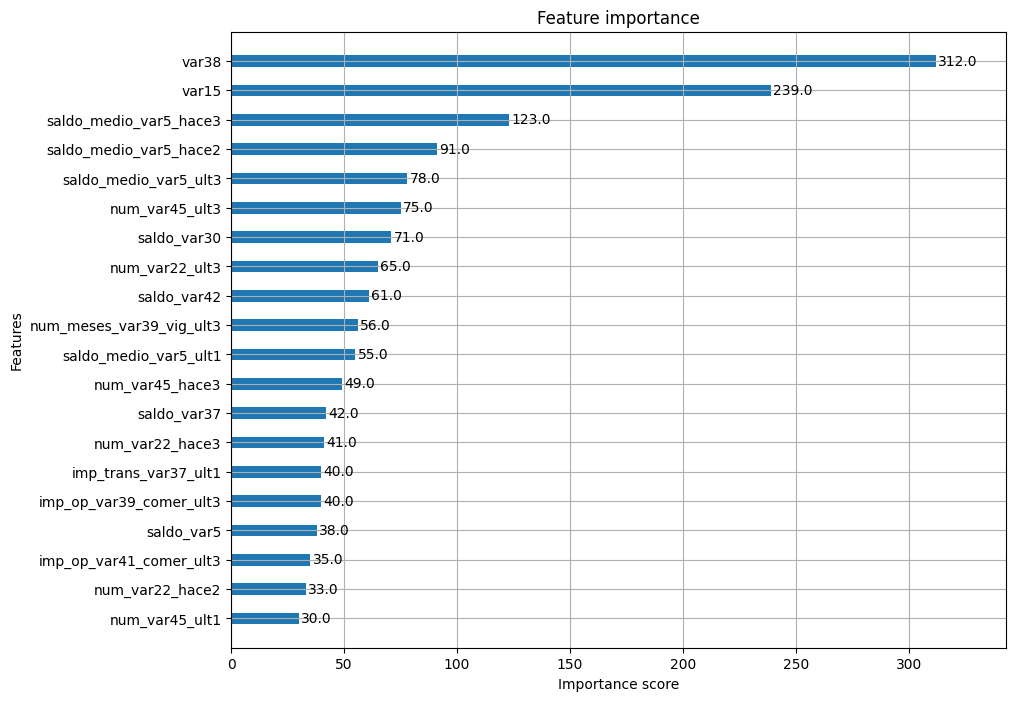

In [27]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

# 그래프의 크기를 설정 (가로 10, 세로 8)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# 피처 중요도 시각화 함수 호출
# 상위 20개의 피처만 표시하며, 막대의 높이를 0.4로 조절
plot_importance(xgb_clf, ax=ax, max_num_features=20, height=0.4)

## 2) LightGBM 사용

In [ ]:
# 11. LightGBM 모델 학습 및 성능 평가
#     XGBoost와 함께 가장 많이 쓰이는 LightGBM 라이브러리를 사용하여 모델을 학습시키고 성능을 확인하는 단계

In [29]:
from lightgbm import LGBMClassifier

# 1. LightGBM 분류기 생성
# (n_estimators가 500이므로, 100회 동안 개선 없으면 멈추도록 설정)
lgbm_clf = LGBMClassifier(n_estimators=500, early_stopping_round=100)

# 2. 모델 학습
# fit() 단계에서는 eval_metric과 eval_set만 전달
eval_set = [(X_tr, y_tr), (X_val, y_val)]
lgbm_clf.fit(X_tr, y_tr, eval_metric="auc", eval_set=eval_set)

# 3. 테스트 데이터 세트로 예측 및 ROC AUC 점수 계산
lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:, 1])
print('LightGBM ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.177166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13308
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[42]	training's auc: 0.91059	training's binary_logloss: 0.112183	valid_1's auc: 0.831787	valid_1's binary_logloss: 0.13527
LightGBM ROC AUC: 0.8384


In [ ]:
# 12. LightGBM 하이퍼 파라미터 검색 공간 설정
#     Hyperopt가 탐색할 하이퍼 파라미터의 범위를 설정하는 과정

In [31]:
# LightGBM을 위한 검색 공간 정의
lgbm_search_space = {
    # 트리가 가질 수 있는 최대 리프 노드 개수 (32~64 사이, 1 간격 정수)
    'num_leaves': hp.quniform('num_leaves', 32, 64, 1),

    # 트리의 최대 깊이 (100~160 사이, 1 간격 정수)
    'max_depth': hp.quniform('max_depth', 100, 160, 1),

    # 최종 결정 노드가 되기 위해 필요한 최소한의 샘플 데이터 수 (60~100 사이, 1 간격 정수)
    'min_child_samples': hp.quniform('min_child_samples', 60, 100, 1),

    # 개별 트리를 학습할 때 무작위로 선택하는 데이터 샘플링 비율 (0.7~1 사이 실수)
    'subsample': hp.uniform('subsample', 0.7, 1),

    # 가중치를 업데이트하는 단계별 크기 (0.01~0.2 사이 실수)
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
}

In [ ]:
# 13. LightGBM용 목적 함수(Objective Function) 정의

In [32]:
def objective_func(search_space):
    # 하이퍼 파라미터 적용 (quniform 값들은 정수형 int로 변환 필수)
    lgbm_clf = LGBMClassifier(
        n_estimators=100,
        num_leaves=int(search_space['num_leaves']),
        max_depth=int(search_space['max_depth']),
        min_child_samples=int(search_space['min_child_samples']),
        subsample=search_space['subsample'],
        learning_rate=search_space['learning_rate'],
        # 최신 버전 에러 방지를 위해 객체 생성 시 조기 중단 설정
        early_stopping_round=30
    )

    roc_auc_list = []

    # 3개 폴드(K-Fold) 분할 방식 적용
    kf = KFold(n_splits=3)

    # X_train을 다시 학습과 검증용 데이터로 분리하여 반복 학습
    for tr_index, val_index in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        # 모델 학습 수행 (eval_metric은 auc로 설정)
        lgbm_clf.fit(X_tr, y_tr,
                     eval_metric="auc",
                     eval_set=[(X_tr, y_tr), (X_val, y_val)])

        # 검증 데이터로 예측 확률 추출 후 ROC AUC 계산
        score = roc_auc_score(y_val, lgbm_clf.predict_proba(X_val)[:, 1])
        roc_auc_list.append(score)

    # Hyperopt는 최솟값을 찾으므로, AUC(클수록 좋음)에 -1을 곱해서 반환
    return -1 * np.mean(roc_auc_list)

In [ ]:
# 14. fmin()을 이용한 LightGBM 최적 파라미터 탐색
#     앞서 정의한 검색 공간과 목적 함수를 연결하여 실제로 가장 좋은 성능을 내는 다이얼 값 탐색

In [33]:
from hyperopt import fmin, tpe, Trials

# 모든 최적화 과정을 기록할 Trials 객체 생성
trials = Trials()

# fmin() 함수를 호출하여 최적 하이퍼 파라미터 추출
best = fmin(fn=objective_func,               # 1단계에서 만든 목적 함수
            space=lgbm_search_space,         # 2단계에서 만든 검색 공간
            algo=tpe.suggest,                # 최적화 알고리즘 (TPE 방식)
            max_evals=50,                    # 총 50번 반복 수행
            trials=trials,                   # 실행 이력 저장
            rstate=np.random.default_rng(seed=30)) # 결과 재현을 위한 난수 고정

print('best:', best)

[LightGBM] [Info] Number of positive: 1579, number of negative: 38965
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.103729 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12827
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 192
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038945 -> initscore=-3.205872
[LightGBM] [Info] Start training from score -3.205872
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[98]	training's auc: 0.88765	training's binary_logloss: 0.121808	valid_1's auc: 0.831519	valid_1's binary_logloss: 0.135868
[LightGBM] [Info] Number of positive: 1609, number of negative: 38935
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066777 seconds.
You can set `force_row_wise=true` 

In [ ]:
# 15. LightGBM 최적 파라미터 적용 최종 학습 및 평가

In [35]:
# 1. Hyperopt로 찾은 최적 파라미터 기반으로 모델 생성
# n_estimators를 500으로 늘려 충분히 학습하되, 조기 중단 설정을 추가
lgbm_clf = LGBMClassifier(n_estimators=500,
                          num_leaves=int(best['num_leaves']),
                          max_depth=int(best['max_depth']),
                          min_child_samples=int(best['min_child_samples']),
                          subsample=round(best['subsample'], 5),
                          learning_rate=round(best['learning_rate'], 5),
                          # 최신 버전 호환을 위해 객체 생성 시 조기 중단 설정
                          early_stopping_round=100)

# 2. 최종 학습 수행
# 검증 데이터 세트(eval_set)를 통해 성능을 모니터링
eval_set = [(X_tr, y_tr), (X_val, y_val)]
lgbm_clf.fit(X_tr, y_tr, eval_metric="auc", eval_set=eval_set)

# 3. 테스트 데이터 세트로 최종 성능(ROC AUC) 평가
lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:, 1])
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13001
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 202
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[77]	training's auc: 0.899119	training's binary_logloss: 0.11717	valid_1's auc: 0.833934	valid_1's binary_logloss: 0.13474
ROC AUC: 0.8412


# **캐글 Decision Tree And Random Forest Classifier Models**

In [ ]:
# 1. 라이브러리 임포트 및 데이터 로드

In [42]:
import numpy as np # 수치 계산 (행렬 연산)
import pandas as pd # 데이터 가공 (데이터프레임)
import matplotlib.pyplot as plt # 정적 그래프 시각화
import seaborn as sns # 통계용 시각화 (고급)
import plotly.graph_objects as go # 인터랙티브 그래프 (상호작용)
import plotly.express as px # 인터랙티브 그래프 (간편형)
import os # 운영체제 파일 시스템 제어

# 캐글 서버 내 데이터셋 폴더(/kaggle/input)를 뒤져서 파일 목록을 출력함
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data = pd.read_csv("drug200.csv")
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [44]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [47]:
data.corr(numeric_only=True)

,Age,Na_to_K
Age,1.000000,-0.063119
Na_to_K,-0.063119,1.000000


In [ ]:
# 2. 상관관계 히트맵 시각화
#    피처들 간의 수치적 관련성을 색상과 숫자로 표현하여 한눈에 파악하는 과정

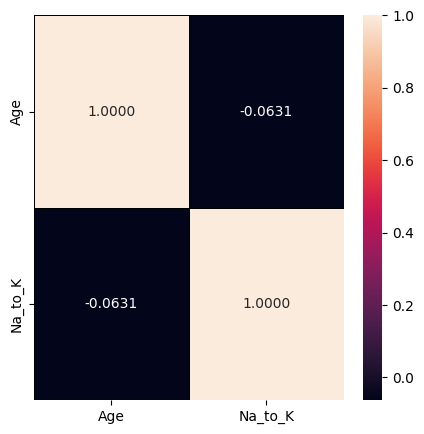

In [49]:
# 그래프의 도화지(f)와 축(ax) 설정 (가로 5, 세로 5 크기)
f, ax = plt.subplots(figsize = (5, 5))

# Seaborn의 히트맵 그리기
sns.heatmap(data.corr(numeric_only=True),
            annot = True,      # 각 칸에 숫자 값 표시
            linewidths = 0.5,  # 칸 사이의 간격 두께
            linecolor = "black", # 칸 사이 간격의 색상
            fmt = ".4f",       # 숫자를 소수점 넷째 자리까지 표시
            ax = ax)           # 설정한 축(ax)에 그래프를 그림

plt.show() # 그래프 출력

[분석] **히트맵(Heatmap) 읽는 법**

1. 상관계수의 범위: 값은 -1에서 1 사이를 갖는다.

* 1에 가까울수록: 양의 상관관계 (A가 커지면 B도 커짐)

* -1에 가까울수록: 음의 상관관계 (A가 커지면 B는 작아짐)

* 0에 가까울수록: 서로 아무 관계가 없음

2. 시각적 해석: 보통 색이 밝거나 아주 짙을수록(절대값이 클수록) 두 변수 간의 관계가 깊다는 뜻이다.

3. 주의 사항: 상관관계가 높다고 해서 반드시 '원인과 결과(인과관계)'인 것은 아니다. 하지만 모델이 학습할 때 어떤 변수들이 서로 얽혀 있는지 파악하는 데 매우 유용하다.

In [ ]:
# 3. 모든 변수 간의 관계 시각화 (Pairplot)
#    변수들 사이의 상관관계와 분포를 약물 종류별 색상으로 구분하여 한꺼번에 확인하는 과정

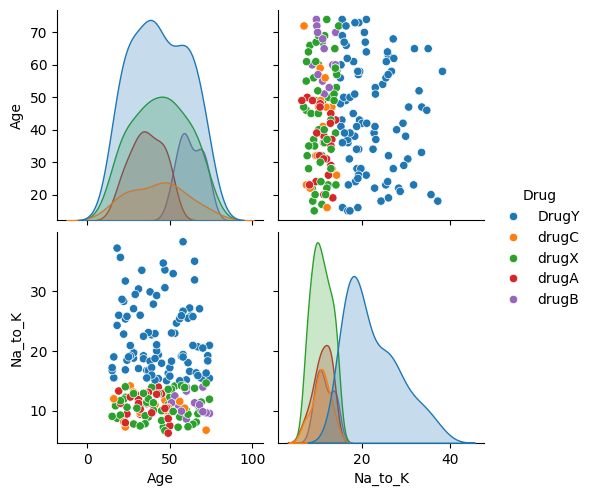

In [50]:
# Seaborn의 페어플롯 그리기
# data: 분석할 데이터프레임
# hue = "Drug": 'Drug' 컬럼의 값(약물 종류)에 따라 색상을 다르게 표시
sns.pairplot(data, hue = "Drug")

# 그래프 출력
plt.show()

[분석] **페어플롯(Pairplot) 분석 가이드**

1. 대각선(Diagonal) 그래프: 자기 자신과의 관계를 나타내며, 해당 변수의 데이터 분포(히스토그램 또는 밀도 추정 곡선)를 보여준다. 특정 약물이 특정 수치 범위에 몰려 있는지 확인 가능하다.

2. 산점도(Scatter Plot): 두 변수 사이의 관계를 점으로 찍어 보여준다.

* 점이 섞여 있다면: 두 변수만으로는 약물을 구분하기 어렵다는 뜻이다.

* 색깔별로 구역이 나뉜다면: 그 두 변수가 약물을 분류하는 데 아주 중요한 **결정적 피처**라는 신호다.

분석 팁: 예를 들어 Na_to_K와 다른 변수의 관계에서 특정 색상(약물)이 위쪽으로 확연히 분리되어 보인다면, 모델이 학습할 때 "나트륨 대비 칼륨 비율이 높으면 이 약이구나!"라고 판단할 근거가 된다.

In [51]:
data.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [52]:
data["Age"].value_counts(dropna=False)

,count
Age,
47,8
23,7
28,7
49,7
32,6
39,6
50,5
60,5
22,5


In [53]:
data["Sex"].value_counts()

,count
Sex,
M,104
F,96


In [54]:
data["BP"].value_counts()

,count
BP,
HIGH,77
LOW,64
NORMAL,59


In [55]:
data["Cholesterol"].value_counts()

,count
Cholesterol,
HIGH,103
NORMAL,97


In [56]:
data["Drug"].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [ ]:
# 4. 나이별 분포 집계 및 시각화
#    환자들의 나이 데이터를 카운트하여 어떤 연령대가 가장 많은지 대화형 그래프로 확인하는 과정

In [57]:
# 1. 나이별 데이터 개수 세기 (결측치 포함)
dataAge = data["Age"].value_counts(dropna = False)

# 2. 시각화를 위해 데이터를 가공하는 과정
npar_dataAge = np.array(dataAge) # 개수(Count)를 넘파이 배열로 변환
x = list(npar_dataAge)           # 다시 리스트로 변환 (그래프의 y축: 인원수)
y = data.Age.value_counts().index # 나이 값들을 추출 (그래프의 x축: 나이)

# 3. 그래프용 데이터프레임 생성
DataAge = {"Age": y, "Number": x}
DataAge = pd.DataFrame(DataAge)

# 4. Plotly Express를 이용한 막대그래프 생성
# x축은 나이(Age), y축은 해당 나이의 인원수(Number)
fig = px.bar(DataAge, x = "Age", y = "Number")

# 그래프 출력
fig.show()

[분석] **데이터 집계와 Plotly 활용**
1. value_counts():
* 시리즈(Series) 객체에서 각 고유값이 몇 번 등장하는지 계산해주는 가장 핵심적인 함수다.
* 기본적으로 내림차순 정렬되므로, 가장 빈도가 높은 나이가 맨 위에 온다.

2. Plotly (px.bar):

* 앞서 사용한 Seaborn과 달리 대화형(Interactive) 그래프를 만든다.

* fig.show()로 출력된 그래프에 마우스를 올리면 정확한 나이와 인원수가 툴팁으로 표시되어 분석이 편리하다.

3. 데이터 구조화:
* 그래프 라이브러리에 따라 데이터를 바로 넣을 수도 있다.
* 하지만 위 코드처럼 별도의 딕셔너리(DataAge)를 만들어 데이터프레임으로 변환 후 넘기는 방식이 관리에 용이하다.

In [ ]:
# 5. 성별 비율 시각화 (Pie Chart)
#    전체 환자 중 남성(M)과 여성(F)의 비율이 각각 어느 정도인지 대화형 원형 그래프로 확인하는 과정

In [58]:
# 1. 사용할 색상 정의 (금색과 청록색)
colors = ['gold', 'mediumturquoise']

# 2. 파이 차트 객체 생성
# labels: 항목 이름 (남성 'M', 여성 'F')
# values: 각 항목의 실제 머릿수 (104명, 96명)
fig = go.Figure(data = [go.Pie(labels= ['M', 'F'], values=[104, 96])])

# 3. 그래프의 세부 디자인 설정 (Traces 업데이트)
fig.update_traces(
    hoverinfo = 'label + percent', # 마우스를 올리면 이름과 퍼센트 표시
    textinfo = 'value',            # 차트 위에 실제 숫자(인원수) 표시
    textfont_size = 20,            # 글자 크기 설정
    marker = dict(                 # 파이 조각의 스타일 설정
        colors = colors,           # 위에서 정의한 색상 적용
        line = dict(color = '#000000', width = 2) # 검은색 테두리 추가
    )
)

# 그래프 출력
fig.show()

[분석] **데이터 시각화의 디테일 (Plotly)**
1. go.Figure vs px: 앞선 막대그래프(px.bar)보다 훨씬 세밀한 설정(테두리 두께, 폰트 크기 등)을 할 때 graph_objects(go)를 주로 사용한다.

2. 시각적 가독성: textinfo='value'와 hoverinfo='percent'를 적절히 섞으면, 그래프 자체에서는 정확한 명수를 보고 비율을 알 수 있어 정보 전달력이 좋아진다.

3. 분석 포인트: 현재 데이터는 남성 104명, 여성 96명으로 성별 균형이 매우 잘 잡힌 데이터셋임을 알 수 있다. (머신러닝 학습 시 특정 성별에 편향되지 않은 좋은 조건이다.)

In [ ]:
# 6. 혈압(BP) 분포 시각화
#    환자들의 혈압 수치가 어느 등급에 가장 많이 분포되어 있는지 확인하는 과정

In [60]:
# Plotly Express를 이용한 막대그래프 생성
# x: 혈압의 등급 (높음, 낮음, 보통)
# y: 각 등급에 해당하는 환자 수 (77명, 64명, 59명)
fig = px.bar(x = ["HIGH", "LOW", "NORMAL"], y = [77, 64, 59])

# 그래프 출력 (대화형 그래프)
fig.show()

[분석] **범주형 데이터의 시각화**
1. 범주형 변수(Categorical Variable): 혈압(BP)처럼 숫자가 아닌 "등급"이나 "이름"으로 나뉘는 데이터를 말한다. 이런 데이터의 특징을 파악할 때는 막대그래프가 가장 효과적이다.

2. 데이터의 균형 확인:

* HIGH(77), LOW(64), NORMAL(59)로 수치가 아주 극단적으로 치우치지 않고 비교적 골고루 분포되어 있다.

* 만약 특정 등급(예: NORMAL)이 1~2명뿐이라면 모델이 그 등급을 학습하기 어려워지는데, 이 데이터는 학습하기에 매우 건강한 상태임을 알 수 있다.

3. Plotly의 간결함: px.bar에 리스트 형태로 x, y 값만 던져주어도 즉시 깔끔한 웹 기반 그래프를 만들어준다.

In [ ]:
# 7. 콜레스테롤(Cholesterol) 분포 시각화
#    환자들의 콜레스테롤 상태가 '높음'인지 '보통'인지 그 비중을 확인하는 과정

In [62]:
# Plotly Express를 이용한 히스토그램(막대그래프 형태) 생성
# x: 콜레스테롤 등급 (HIGH: 높음, NORMAL: 보통)
# y: 각 등급에 해당하는 환자 수 (103명, 97명)
fig = px.histogram(x = ["HIGH", "NORMAL"], y = [103, 97])

# 그래프 출력
fig.show()

In [ ]:
# 8. 타겟 데이터(Drug) 분포 시각화
#    우리가 맞춰야 할 정답인 약물 종류별 비중을 파이 차트로 확인하는 과정

In [63]:
# 1. 파이 차트 객체 생성
# labels: 약물의 종류 (DrugY, X, A, C, B)
# values: 각 약물별 데이터 개수 (91, 54, 23, 16, 16)
fig = go.Figure(data = [go.Pie(labels=["DrugY","DrugX","DrugA","DrugC","DrugB"],
                               values=[91, 54, 23, 16, 16])])

# 2. 그래프 디자인 및 정보 표시 설정
fig.update_traces(
    hoverinfo = 'label + percent', # 마우스를 올리면 약물 이름과 백분율 표시
    textinfo = 'value',            # 차트 위에 실제 데이터 개수 표시
    textfont_size = 20,            # 글자 크기 20으로 설정
    marker = dict(
        colors = px.colors.sequential.RdBu, # RdBu(Red-Blue) 컬러 팔레트 적용
        line = dict(color = '#000000', width = 2) # 검은색 테두리 두께 2
    )
)

# 그래프 출력
fig.show()

In [ ]:
# 9. 나이와 나트륨/칼륨 비율(Na_to_K)의 관계 시각화
#    두 핵심 변수의 조합이 약물 처방(정답)에 어떤 영향을 주는지 입체적으로 확인하는 과정

In [64]:
# Plotly Express를 이용한 산점도(Scatter Plot) 생성
# x: 나트륨 대비 칼륨 비율 (Na_to_K)
# y: 환자의 나이 (Age)
# color: 약물의 종류에 따라 점의 색상을 다르게 표시 (Drug)
# size: 나이가 많을수록 점의 크기를 크게 설정 (Age)
# hover_data: 마우스를 올렸을 때 추가로 보여줄 정보 (Na_to_K)
fig = px.scatter(data, x = "Na_to_K", y="Age", color="Drug",
                 size='Age', hover_data=['Na_to_K'])

# 그래프 출력
fig.show()


[분석] **피처 간 관계와 결정 경계**(Decision Boundary)

1. 결정적 피처 발견: 이 그래프를 보면 특정 구역에 특정 색상의 점들이 몰려 있는 것을 볼 수 있습니다. 특히 Na_to_K 수치가 약 15 이상인 구간에서는 나이에 상관없이 대부분 DrugY가 처방되는 패턴이 나타납니다.

2. 산점도의 힘: 단일 변수(나이만 보거나, 비율만 볼 때)로는 알 수 없었던 두 변수의 조합이 만드는 규칙을 찾아낼 수 있습니다. 모델(의사결정 트리 등)은 바로 이런 시각적인 경계선을 수학적으로 찾아내는 역할을 합니다.

3. 시각화 요소의 활용:

* 색상(Color): 범주형 정답(Drug)을 구분할 때 가장 효과적입니다.

* 크기(Size): 데이터의 또 다른 수치적 특성(여기서는 Age)을 동시에 표현하여 3차원적인 정보를 2차원 평면에 담아냅니다.

In [71]:
dataclass = pd.read_csv("drug200.csv")
dataclass
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [76]:
dataclass.Sex = [1 if i == "F" else 0 for i in dataclass.Sex]
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,HIGH,HIGH,25.355,4
1,47,0,LOW,HIGH,13.093,1
2,47,0,LOW,HIGH,10.114,1
3,28,0,NORMAL,HIGH,7.798,3
4,61,0,LOW,HIGH,18.043,4
...,...,...,...,...,...,...
195,56,0,LOW,HIGH,11.567,1
196,16,0,LOW,HIGH,12.006,1
197,52,0,NORMAL,HIGH,9.894,3
198,23,0,NORMAL,NORMAL,14.020,3


In [77]:
import warnings
warnings.filterwarnings('ignore')

for i in range(0,len(dataclass.BP)):
    if dataclass.BP[i] == "LOW":
        dataclass.BP[i] = 2

    elif dataclass.BP[i] == "NORMAL":
        dataclass.BP[i] = 1

    else:
        dataclass.BP[i] = 0

dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,HIGH,25.355,4
1,47,0,2,HIGH,13.093,1
2,47,0,2,HIGH,10.114,1
3,28,0,1,HIGH,7.798,3
4,61,0,2,HIGH,18.043,4
...,...,...,...,...,...,...
195,56,0,2,HIGH,11.567,1
196,16,0,2,HIGH,12.006,1
197,52,0,1,HIGH,9.894,3
198,23,0,1,NORMAL,14.020,3


In [78]:
dataclass.Cholesterol = [1 if i == "HIGH" else 0 for i in dataclass.Cholesterol]
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,1,25.355,4
1,47,0,2,1,13.093,1
2,47,0,2,1,10.114,1
3,28,0,1,1,7.798,3
4,61,0,2,1,18.043,4
...,...,...,...,...,...,...
195,56,0,2,1,11.567,1
196,16,0,2,1,12.006,1
197,52,0,1,1,9.894,3
198,23,0,1,0,14.020,3


In [81]:
import warnings
warnings.filterwarnings('ignore')

for i in range(0,len(dataclass)):
    if dataclass.Drug[i] == "DrugY":
        dataclass.Drug[i] = 4
    elif dataclass.Drug[i] == "drugX":
        dataclass.Drug[i] = 3
    elif dataclass.Drug[i] == "drugA":
        dataclass.Drug[i] = 2
    elif dataclass.Drug[i] == "drugC":
        dataclass.Drug[i] = 1
    else:
        dataclass.Drug[i] = 0

dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,1,25.355,0
1,47,0,2,1,13.093,0
2,47,0,2,1,10.114,0
3,28,0,1,1,7.798,0
4,61,0,2,1,18.043,0
...,...,...,...,...,...,...
195,56,0,2,1,11.567,0
196,16,0,2,1,12.006,0
197,52,0,1,1,9.894,0
198,23,0,1,0,14.020,0


In [82]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.5+ KB


In [83]:
data_types_dict = {'BP': int, "Drug": int}

dataclass = dataclass.astype(data_types_dict)

dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [87]:
x_data = dataclass.drop(["Drug"], axis = 1)
y_data = dataclass.Drug.values

In [88]:
x_data

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,1,25.355
1,47,0,2,1,13.093
2,47,0,2,1,10.114
3,28,0,1,1,7.798
4,61,0,2,1,18.043
...,...,...,...,...,...
195,56,0,2,1,11.567
196,16,0,2,1,12.006
197,52,0,1,1,9.894
198,23,0,1,0,14.020


In [89]:
y_data

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [90]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

dtc = DecisionTreeClassifier()

# Fit the model
dtc.fit(x_train, y_train)

# Predict the x_test
predict = dtc.predict(x_test)

print('The accuracy of the Decision Tree is',metrics.accuracy_score(predict,y_test))

The accuracy of the Decision Tree is 1.0


In [92]:
DTC_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)


# Fit the model
DTC_gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [94]:
y_pred_gini = DTC_gini.predict(x_test)

In [98]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 1.0000


In [99]:
y_pred_train_gini = DTC_gini.predict(x_train)

y_pred_train_gini

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [100]:
print('Training-set accuracy score: {0:0.4f}'.format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 1.0000


In [101]:
# Print the scores on training and test set

print('Training set score: {:.4f}'.format(DTC_gini.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(DTC_gini.score(x_test, y_test)))

Training set score: 1.0000
Test set score: 1.0000


In [102]:
# instantiate the DecisionTreeClassifier model with criterion entropy
DTC_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)


# Fit the model
DTC_en.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [104]:
y_pred_en = DTC_en.predict(x_test)

In [105]:
print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 1.0000


In [106]:
y_pred_train_en = DTC_en.predict(x_train)

y_pred_train_en

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [107]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 1.0000


In [108]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(DTC_en.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(DTC_en.score(x_test, y_test)))

Training set score: 1.0000
Test set score: 1.0000


In [109]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state = 0)

# Fit the model
rfc.fit(x_train, y_train)

# Predict the model
predict = rfc.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 1.0


In [110]:
from sklearn.ensemble import RandomForestClassifier

rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)

# Fit the model
rfc_100.fit(x_train, y_train)

# Predict the model
predict = rfc_100.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 1.0


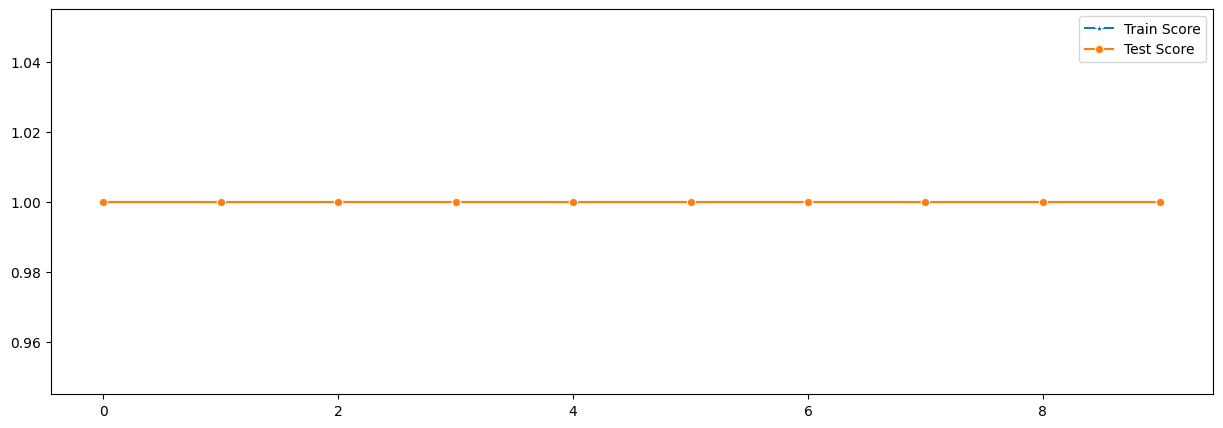

In [112]:
# In this chapter, I want to find the best random_state value.
test_score_list = []
train_score_list = []

for i in range(0,10):
    rfc2 = RandomForestClassifier(random_state=i)
    rfc2.fit(x_train, y_train)
    test_score_list.append(rfc2.score(x_test, y_test))
    train_score_list.append(rfc2.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0, 10), y=train_score_list, marker='*', label='Train Score')
p = sns.lineplot(x=range(0, 10), y=test_score_list, marker='o', label='Test Score')

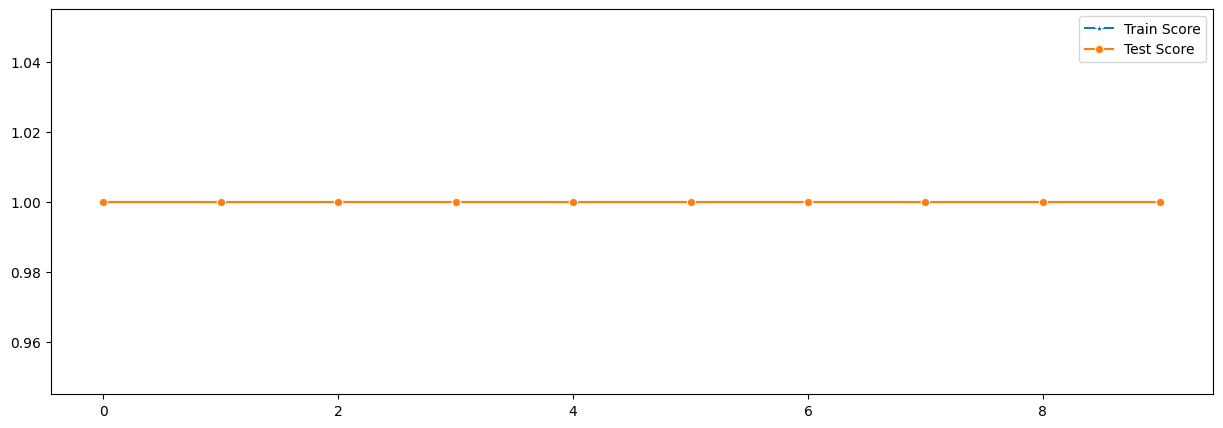

In [119]:
# I found the best random_stete value is five. Now I will find the best n_estimators parameter.
test_score_list = []
train_score_list = []

list_n_estimators = [10,20,30,40,50,60,70,80,90,100]


for i in range(0,len(list_n_estimators)):
    rfc3 = RandomForestClassifier(n_estimators=list_n_estimators[i], random_state=5)
    rfc3.fit(x_train, y_train)
    test_score_list.append(rfc3.score(x_test, y_test))
    train_score_list.append(rfc3.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0, len(list_n_estimators)), y=train_score_list, marker='*', label='Train Score')
p = sns.lineplot(x=range(0, len(list_n_estimators)), y=test_score_list, marker='o', label='Test Score')

In [120]:
last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# fit the model
last_rfc.fit(x_train,y_train)

predict = last_rfc.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 1.0


In [121]:
y_pred_en = last_rfc.predict(x_test)

In [122]:
print('Model accuracy score with best parameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with best parameters: 1.0000


In [123]:
y_pred_train_en = last_rfc.predict(x_train)

y_pred_train_en

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [124]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 1.0000


In [125]:
# print the scores with best parameters on training and test set

print('Training set score: {:.4f}'.format(last_rfc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(last_rfc.score(x_test, y_test)))

Training set score: 1.0000
Test set score: 1.0000


In [126]:
# For Desicion Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

cm_des = DecisionTreeClassifier()

# fit the model
cm_des.fit(x_train,y_train)

y_pred_cm = cm_des.predict(x_test)
y_true = y_test

cm_des1 = confusion_matrix( y_true, y_pred_cm)
cm_des1

array([[60]])

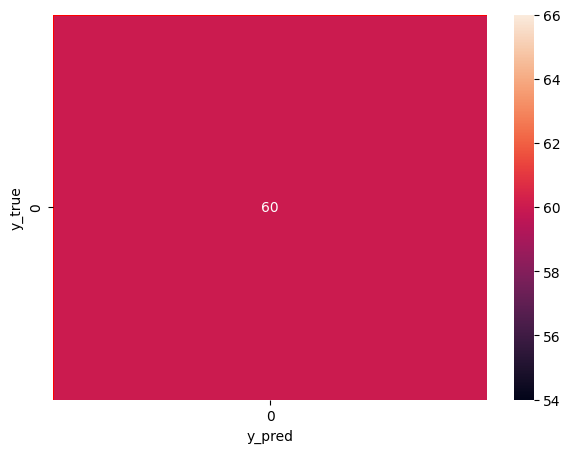

In [127]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des1, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [128]:
cm_des_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# fit the model
cm_des_gini.fit(x_train,y_train)

y_pred_cm = cm_des_gini.predict(x_test)
y_true = y_test

cm_des2 = confusion_matrix( y_true, y_pred_cm)
cm_des2

array([[60]])

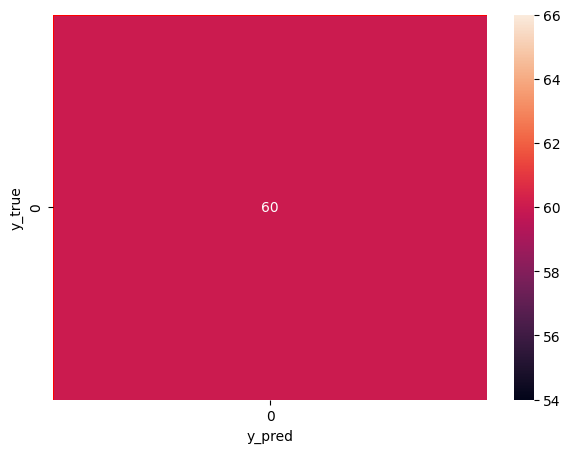

In [129]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des2, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [130]:
cm_last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# Fit The Model
cm_last_rfc.fit(x_train, y_train)

y_pred_cm = cm_last_rfc.predict(x_test)
y_true = y_test

cm_rfc = confusion_matrix(y_true, y_pred_cm)
cm_rfc

array([[60]])

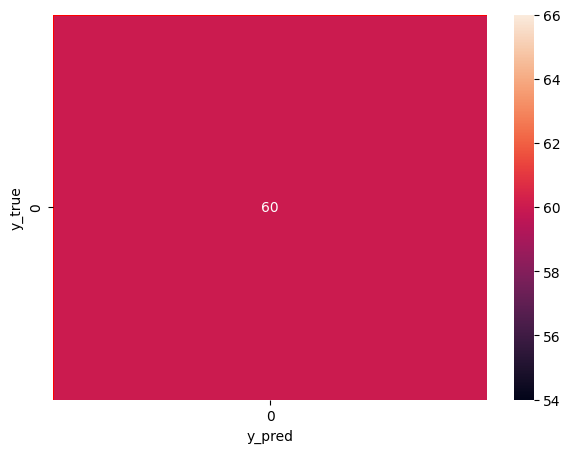

In [131]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_rfc, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [ ]:
# 뭔가 잘못되었네요

# **캐글 Beginner Friendly CatBoost with Optuna**

In [133]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00


In [135]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import KFold,cross_val_score, RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer

from sklearn.model_selection import KFold, cross_val_predict, train_test_split,GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,classification_report

#importing plotly and cufflinks in offline mode
import cufflinks as cf
import plotly.offline
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)


import plotly
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import missingno as msno

import warnings
warnings.filterwarnings("ignore")

In [139]:
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',900)

pd.set_option('display.max_colwidth',200)

df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [141]:
df.duplicated().sum()

np.int64(0)

In [142]:
def missing (df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values

missing(df)

,Missing_Number,Missing_Percent
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


In [143]:
numerical= df.drop(['HeartDisease'], axis=1).select_dtypes('number').columns

categorical = df.select_dtypes('object').columns

print(f'Numerical Columns:  {df[numerical].columns}')
print('\n')
print(f'Categorical Columns: {df[categorical].columns}')

Numerical Columns:  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')


Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [157]:
df[categorical].nunique()

,0
Sex,2
ChestPainType,4
RestingECG,3
ExerciseAngina,2
ST_Slope,3


In [158]:
y = df['HeartDisease']
print(f'Percentage of patient had a HeartDisease:  {round(y.value_counts(normalize=True)[1]*100,2)} %  --> ({y.value_counts()[1]} patient)\nPercentage of patient did not have a HeartDisease: {round(y.value_counts(normalize=True)[0]*100,2)}  %  --> ({y.value_counts()[0]} patient)')

Percentage of patient had a HeartDisease:  55.34 %  --> (508 patient)
Percentage of patient did not have a HeartDisease: 44.66  %  --> (410 patient)


In [160]:
df[numerical].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000


In [162]:
skew_limit = 0.75 # This is our threshold-limit to evaluate skewness. Overall below abs(1) seems acceptable for the linear models.
skew_vals = df[numerical].drop('FastingBS', axis=1).skew()
skew_cols= skew_vals[abs(skew_vals)> skew_limit].sort_values(ascending=False)
skew_cols

,0
Oldpeak,1.022872


In [ ]:
# 최신 Numpy의 iplot()과의 버전 충돌으로 시각화 부분 전부 건너뛰었습니다.

In [164]:
df[categorical].head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


In [166]:
print (f'A female person has a probability of {round(df[df["Sex"]=="F"]["HeartDisease"].mean()*100,2)} % have a HeartDisease')

print()

print (f'A male person has a probability of {round(df[df["Sex"]=="M"]["HeartDisease"].mean()*100,2)} % have a HeartDisease')

print()

A female person has a probability of 25.91 % have a HeartDisease

A male person has a probability of 63.17 % have a HeartDisease



In [167]:
df.groupby('ChestPainType')['HeartDisease'].mean().sort_values(ascending=False)

,HeartDisease
ChestPainType,
ASY,0.790323
TA,0.434783
NAP,0.354680
ATA,0.138728


In [169]:
df.groupby('RestingECG')['HeartDisease'].mean().sort_values(ascending=False)

,HeartDisease
RestingECG,
ST,0.657303
LVH,0.563830
Normal,0.516304


In [170]:
df.groupby('ExerciseAngina')['HeartDisease'].mean().sort_values(ascending=False)

,HeartDisease
ExerciseAngina,
Y,0.851752
N,0.351005


In [171]:
df.groupby('ST_Slope')['HeartDisease'].mean().sort_values(ascending=False)

,HeartDisease
ST_Slope,
Flat,0.828261
Down,0.777778
Up,0.197468


In [172]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')


model = DummyClassifier(strategy='constant', constant=1)
pipe = make_pipeline(ct, model)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))
print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['DummyClassifier']
dummy_result_df = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
dummy_result_df

model : DummyClassifier(constant=1, strategy='constant') and  accuracy score is : 0.5942


,Accuracy
DummyClassifier,0.5942


In [173]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')


lr = LogisticRegression(solver='liblinear')
lda= LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]

for model in models:
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Logistic','LinearDiscriminant','SVM','KNeighbors']
result_df1 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df1

model : LogisticRegression(solver='liblinear') and  accuracy score is : 0.8841
model : LinearDiscriminantAnalysis() and  accuracy score is : 0.8696
model : SVC() and  accuracy score is : 0.7246
model : KNeighborsClassifier() and  accuracy score is : 0.7174


,Accuracy
Logistic,0.8841
LinearDiscriminant,0.8696
SVM,0.7246
KNeighbors,0.7174


In [174]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
s= StandardScaler()
ct1= make_column_transformer((ohe,categorical),(s,numerical))


lr = LogisticRegression(solver='liblinear')
lda= LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]

for model in models:
    pipe = make_pipeline(ct1, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Logistic_scl','LinearDiscriminant_scl','SVM_scl','KNeighbors_scl']
result_df2 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df2

model : LogisticRegression(solver='liblinear') and  accuracy score is : 0.8804
model : LinearDiscriminantAnalysis() and  accuracy score is : 0.8696
model : SVC() and  accuracy score is : 0.8841
model : KNeighborsClassifier() and  accuracy score is : 0.8841


,Accuracy
Logistic_scl,0.8804
LinearDiscriminant_scl,0.8696
SVM_scl,0.8841
KNeighbors_scl,0.8841


In [175]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')

ada = AdaBoostClassifier(random_state=0)
gb = GradientBoostingClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
et=  ExtraTreesClassifier(random_state=0)



models = [ada,gb,rf,et]

for model in models:
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Ada','Gradient','Random','ExtraTree']
result_df3 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df3

model : AdaBoostClassifier(random_state=0) and  accuracy score is : 0.8732
model : GradientBoostingClassifier(random_state=0) and  accuracy score is : 0.8768
model : RandomForestClassifier(random_state=0) and  accuracy score is : 0.8877
model : ExtraTreesClassifier(random_state=0) and  accuracy score is : 0.8804


,Accuracy
Ada,0.8732
Gradient,0.8768
Random,0.8877
ExtraTree,0.8804


In [176]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')

xgbc = XGBClassifier(random_state=0)
lgbmc=LGBMClassifier(random_state=0)


models = [xgbc,lgbmc]

for model in models:
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))

model_names = ['XGBoost','LightGBM']
result_df4 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df4

[LightGBM] [Info] Number of positive: 344, number of negative: 298
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 354
[LightGBM] [Info] Number of data points in the train set: 642, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.535826 -> initscore=0.143548
[LightGBM] [Info] Start training from score 0.143548
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

,Accuracy
XGBoost,0.8478
LightGBM,0.8732


In [178]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != float)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0)

model.fit(X_train, y_train,cat_features=categorical_features_indices,eval_set=(X_test, y_test))
y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))

model_names = ['Catboost_default']
result_df5 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df5

,Accuracy
Catboost_default,0.8804


In [181]:
def objective(trial):
    X= df.drop('HeartDisease', axis=1)
    y= df['HeartDisease']
    categorical_features_indices = np.where(X.dtypes != float)[0]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    param = {
        "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 1, 12),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical(
            "bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]
        ),
        "used_ram_limit": "3gb",
    }

    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    cat_cls = CatBoostClassifier(**param)

    cat_cls.fit(X_train, y_train, eval_set=[(X_test, y_test)], cat_features=categorical_features_indices,verbose=0, early_stopping_rounds=100)

    preds = cat_cls.predict(X_test)
    pred_labels = np.rint(preds)
    accuracy = accuracy_score(y_test, pred_labels)
    return accuracy


if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=50, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))

[I 2026-04-04 14:45:38,864] A new study created in memory with name: no-name-a7cd853a-4626-4f80-b4f1-ee342b5311f1
[I 2026-04-04 14:45:43,004] Trial 0 finished with value: 0.8840579710144928 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.04964437380595762, 'depth': 11, 'boosting_type': 'Plain', 'bootstrap_type': 'Bayesian', 'bagging_temperature': 2.424647833937051}. Best is trial 0 with value: 0.8840579710144928.
[I 2026-04-04 14:45:50,166] Trial 1 finished with value: 0.8804347826086957 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.07275459230299273, 'depth': 9, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'bagging_temperature': 9.163664913461224}. Best is trial 0 with value: 0.8840579710144928.
[I 2026-04-04 14:45:52,185] Trial 2 finished with value: 0.8876811594202898 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.06957254525325628, 'depth': 7, 'boosting_type': 'Plain', 'bootstrap_type': 'MVS'}. Best is t

Number of finished trials: 50
Best trial:
  Value: 0.9094202898550725
  Params: 
    objective: CrossEntropy
    colsample_bylevel: 0.09856800048168109
    depth: 10
    boosting_type: Ordered
    bootstrap_type: MVS


In [183]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != float)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0,
                          objective= 'CrossEntropy',
    colsample_bylevel= 0.04292240490294766,
    depth= 10,
    boosting_type= 'Plain',
    bootstrap_type= 'MVS')

model.fit(X_train, y_train,cat_features=categorical_features_indices,eval_set=(X_test, y_test))
y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))
print(classification_report(y_test, y_pred))

model_names = ['Catboost_tuned']
result_df6 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df6

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       112
           1       0.93      0.91      0.92       164

    accuracy                           0.91       276
   macro avg       0.90      0.91      0.91       276
weighted avg       0.91      0.91      0.91       276



,Accuracy
Catboost_tuned,0.9094
